/var/folders/rj/qvl7_hj55nvf0pv02cvsnh240000gn/T/ipykernel_68443/2245360536.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.corrcoef(g['Accuracy'], g['Similarity'])[0, 1]) \


  Algorithm Similarity Metric  Actual Correlation  Target Corr Sign
0     Alg-A          Metric-1            0.974363                 1
1     Alg-A          Metric-2           -0.982727                -1
2     Alg-A          Metric-3            0.926592                 1
3     Alg-B          Metric-1            0.873191                 1
4     Alg-B          Metric-2           -0.971433                -1
5     Alg-B          Metric-3            0.979667                 1
6     Alg-C          Metric-1            0.941538                 1
7     Alg-C          Metric-2           -0.974081                -1
8     Alg-C          Metric-3            0.996702                 1


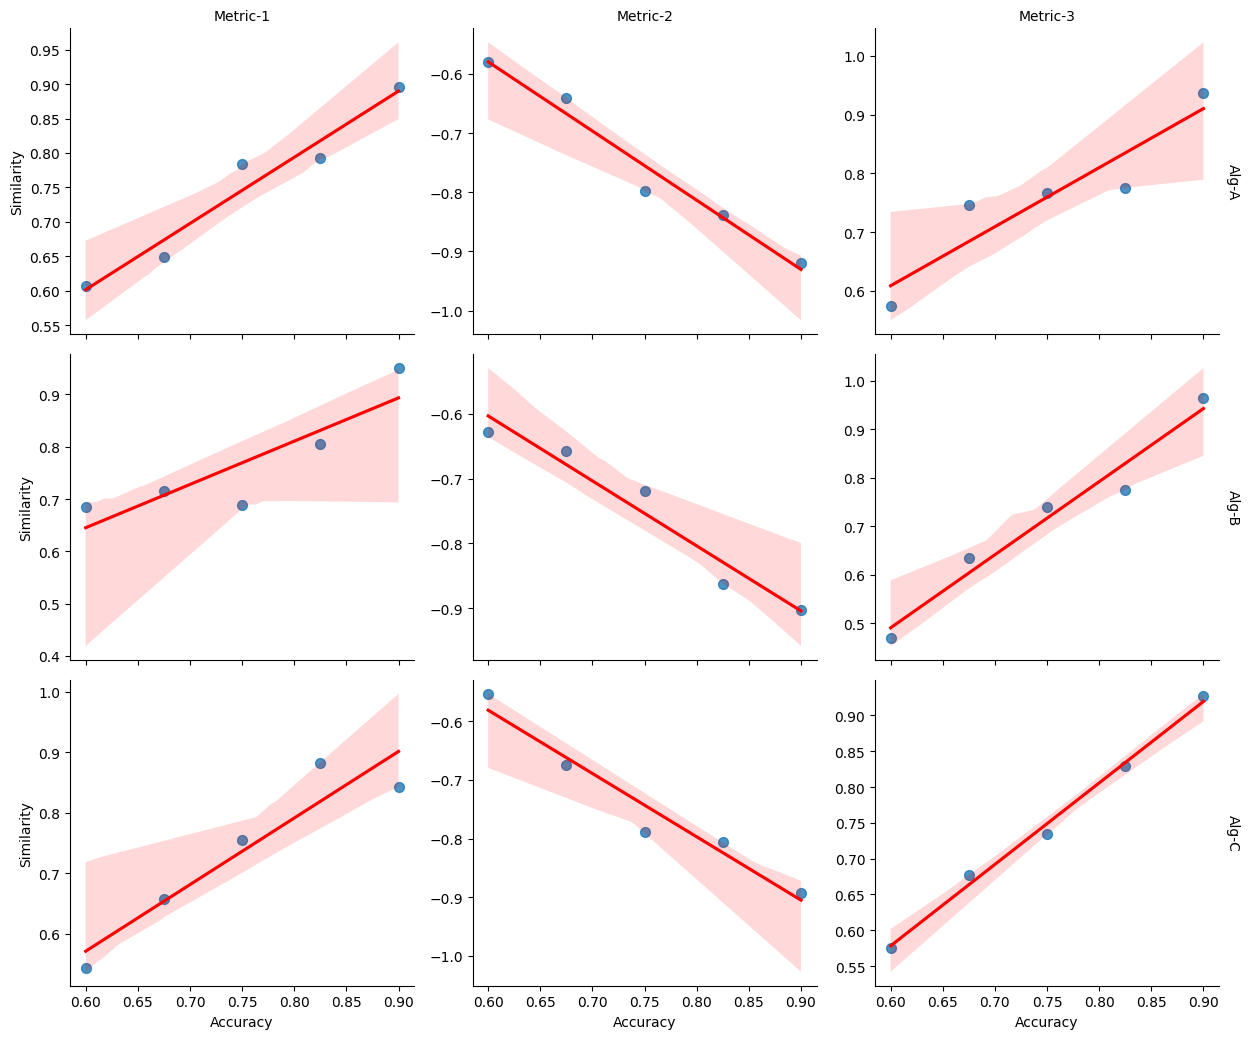

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Settings
algorithms = ['Alg-A', 'Alg-B', 'Alg-C']
similarity_metrics = ['Metric-1', 'Metric-2', 'Metric-3']
n_points = 5

# Desired correlation direction
correlation_signs = {
    'Metric-1': +1,
    'Metric-2': -1,
    'Metric-3': +1
}

# Noise level
noise_std = 0.04

rows = []
for alg in algorithms:
    accuracies = np.linspace(0.6, 0.9, n_points)
    for sim_metric in similarity_metrics:
        sign = correlation_signs[sim_metric]
        slope = 1.0 * sign
        intercept = 0.0

        noise = np.random.normal(loc=0.0, scale=noise_std, size=n_points)
        similarities = slope * accuracies + intercept + noise

        for acc, sim in zip(accuracies, similarities):
            rows.append({
                'Algorithm': alg,
                'Similarity Metric': sim_metric,
                'Accuracy': acc,
                'Similarity': sim,
                'Target Corr Sign': sign
            })

df = pd.DataFrame(rows)

# Compute correlation
correlations = df.groupby(['Algorithm', 'Similarity Metric']) \
    .apply(lambda g: np.corrcoef(g['Accuracy'], g['Similarity'])[0, 1]) \
    .rename("Actual Correlation").reset_index()

correlations['Target Corr Sign'] = correlations['Similarity Metric'].map(correlation_signs)

print(correlations)

g = sns.lmplot(
    data=df,
    x="Accuracy",
    y="Similarity",
    col="Similarity Metric",
    row="Algorithm",
    height=3.5,
    aspect=1.2,
    scatter_kws={"s": 50},   # size of scatter dots
    line_kws={"color": "red"},  # regression line color
    facet_kws={'margin_titles': True, 'sharey': False}
)

g.set_titles(row_template='{row_name}', col_template='{col_name}')
plt.tight_layout()
plt.show()